In [1]:
# ==============================================================================
# CÉLULA 1 — Imports e carregamento
# ==============================================================================
import json
import random
import numpy as np
import pandas as pd
from collections import Counter
from datasets import load_dataset

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

val   = load_dataset("yale-nlp/FOLIO", split="validation")
train = load_dataset("yale-nlp/FOLIO", split="train")

print(f"Validação : {len(val)} exemplos")
print(f"Treino    : {len(train)} exemplos")



/home/romulo-torres/ufam/pibic/informacoes_reproducao_pibic/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Validação : 203 exemplos
Treino    : 1001 exemplos


In [2]:

# ==============================================================================
# CÉLULA 2 — Distribuição atual da validação (referência)
# ==============================================================================
val_labels = [ex["label"] for ex in val]
val_counts = Counter(val_labels)
val_total  = len(val_labels)

print("=== VALIDAÇÃO — distribuição de referência ===")
for label in ["True", "False", "Uncertain"]:
    n   = val_counts[label]
    pct = n / val_total * 100
    print(f"  {label:10s}: {n:4d}  ({pct:.1f}%)")



=== VALIDAÇÃO — distribuição de referência ===
  True      :   72  (35.5%)
  False     :   62  (30.5%)
  Uncertain :   69  (34.0%)


In [3]:

# ==============================================================================
# CÉLULA 3 — Parâmetros da amostragem
# ==============================================================================
# Quantos exemplos do TREINO você quer adicionar à validação?
# 203 (val) * 2.6 ≈ 528 total  →  ~325 novos exemplos do treino
N_NOVOS = 325   # ← ajuste aqui se quiser

# Proporção alvo = mesma da validação
proporcao_alvo = {k: v / val_total for k, v in val_counts.items()}

# Quantos de cada label precisamos pegar do treino
cotas = {
    label: round(proporcao * N_NOVOS)
    for label, proporcao in proporcao_alvo.items()
}

# Pequeno ajuste para bater exatamente N_NOVOS
diferenca = N_NOVOS - sum(cotas.values())
# Distribui o resto no label mais frequente
label_mais_freq = max(cotas, key=lambda l: cotas[l])
cotas[label_mais_freq] += diferenca

print(f"\n=== COTAS PARA {N_NOVOS} NOVOS EXEMPLOS ===")
for label, n in cotas.items():
    print(f"  {label:10s}: {n:4d}")
print(f"  {'TOTAL':10s}: {sum(cotas.values()):4d}")




=== COTAS PARA 325 NOVOS EXEMPLOS ===
  Uncertain :  110
  True      :  116
  False     :   99
  TOTAL     :  325


In [10]:
# ==============================================================================
# CÉLULA 4 — Sortear aleatoriamente (sem estratificação forçada)
# ==============================================================================
todos_indices = list(range(len(train)))
todos_selecionados = sorted(random.sample(todos_indices, N_NOVOS))

print(f"✅ Total selecionado: {len(todos_selecionados)} exemplos do treino")

✅ Total selecionado: 325 exemplos do treino


In [11]:

# ==============================================================================
# CÉLULA 5 — Verificação: distribuição da amostra selecionada
# ==============================================================================
train_labels_sel = [train[i]["label"] for i in todos_selecionados]
sel_counts = Counter(train_labels_sel)

print("=== DISTRIBUIÇÃO DA AMOSTRA SELECIONADA ===")
for label in ["True", "False", "Uncertain"]:
    n_sel = sel_counts[label]
    pct   = n_sel / len(todos_selecionados) * 100
    print(f"  {label:10s}: {n_sel:4d}  ({pct:.1f}%)")

print("\n=== COMPARAÇÃO: VALIDAÇÃO vs SELECIONADOS vs COMBINADO ===")
combinado_total = val_total + len(todos_selecionados)
print(f"{'Label':<12} {'Val n':>6} {'Val %':>7} {'Sel n':>6} {'Sel %':>7} {'Comb n':>7} {'Comb %':>8}")
print("-" * 60)
for label in ["True", "False", "Uncertain"]:
    nv  = val_counts[label]
    ns  = sel_counts[label]
    nc  = nv + ns
    print(
        f"{label:<12} {nv:>6} {nv/val_total*100:>6.1f}%"
        f" {ns:>6} {ns/len(todos_selecionados)*100:>6.1f}%"
        f" {nc:>7} {nc/combinado_total*100:>7.1f}%"
    )
print(f"{'TOTAL':<12} {val_total:>6} {'100.0%':>7} {len(todos_selecionados):>6} {'100.0%':>7} {combinado_total:>7} {'100.0%':>8}")



=== DISTRIBUIÇÃO DA AMOSTRA SELECIONADA ===
  True      :  117  (36.0%)
  False     :  105  (32.3%)
  Uncertain :  103  (31.7%)

=== COMPARAÇÃO: VALIDAÇÃO vs SELECIONADOS vs COMBINADO ===
Label         Val n   Val %  Sel n   Sel %  Comb n   Comb %
------------------------------------------------------------
True             72   35.5%    117   36.0%     189    35.8%
False            62   30.5%    105   32.3%     167    31.6%
Uncertain        69   34.0%    103   31.7%     172    32.6%
TOTAL           203  100.0%    325  100.0%     528   100.0%


In [12]:

# ==============================================================================
# CÉLULA 6 — Verificação: complexidade (nl_wc e fol_tc) da amostra
# ==============================================================================
import string, re

def word_count(text):
    translator = str.maketrans('', '', string.punctuation)
    return len(text.translate(translator).split())

def count_logic_tokens(text):
    text = text.replace("->", "->").replace(".", "")
    patterns = [
        r'[\u2200\u2203]',
        r'[\xac\u2227\u2228\u2192\u2194\u27f7\u21d4\u27ba\u2295]',
        r'[=\u2260]', r'[(),]',
        r'[a-zA-Z_][a-zA-Z0-9_]*', r'\s+'
    ]
    token_pattern = re.compile('|'.join(patterns))
    tokens = token_pattern.findall(text)
    return len([t for t in tokens if not t.isspace()])

def complexidade(ex):
    return {
        "nl_wc":  word_count(ex['premises'] + ex['conclusion']),
        "fol_tc": count_logic_tokens(ex['premises-FOL'] + ex['conclusion-FOL']),
    }

val_comp   = pd.DataFrame([complexidade(ex) for ex in val])
train_comp = pd.DataFrame([complexidade(train[i]) for i in todos_selecionados])

print("=== COMPLEXIDADE: VALIDAÇÃO vs SELECIONADOS ===")
print(f"\n{'Métrica':<10} {'Val mean':>10} {'Val std':>9} {'Sel mean':>10} {'Sel std':>9}")
print("-" * 52)
for col in ["nl_wc", "fol_tc"]:
    print(
        f"{col:<10}"
        f" {val_comp[col].mean():>10.1f} {val_comp[col].std():>9.1f}"
        f" {train_comp[col].mean():>10.1f} {train_comp[col].std():>9.1f}"
    )



=== COMPLEXIDADE: VALIDAÇÃO vs SELECIONADOS ===

Métrica      Val mean   Val std   Sel mean   Sel std
----------------------------------------------------
nl_wc            68.9      34.8       69.6      33.4
fol_tc          118.1      57.8      111.9      52.2


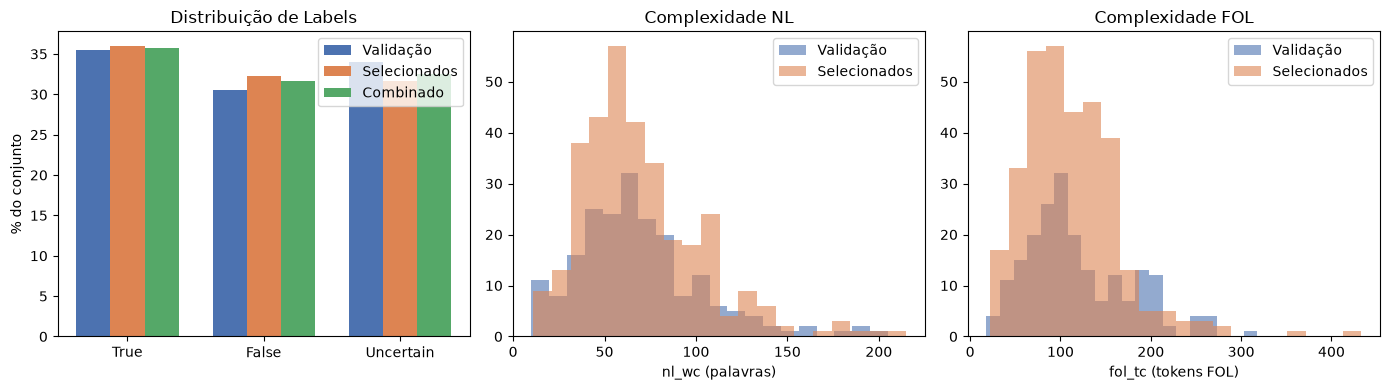

Figura salva em distribuicao_amostragem.png


In [13]:

# ==============================================================================
# CÉLULA 7 — Visualização rápida das distribuições
# ==============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Labels
labels_ordem = ["True", "False", "Uncertain"]
x = range(len(labels_ordem))
nv = [val_counts[l]              for l in labels_ordem]
ns = [sel_counts[l]              for l in labels_ordem]
nc = [val_counts[l]+sel_counts[l] for l in labels_ordem]

ax = axes[0]
width = 0.25
ax.bar([i - width for i in x], [v/val_total*100 for v in nv],   width, label="Validação", color="#4C72B0")
ax.bar([i         for i in x], [v/len(todos_selecionados)*100 for v in ns], width, label="Selecionados", color="#DD8452")
ax.bar([i + width for i in x], [v/combinado_total*100 for v in nc], width, label="Combinado", color="#55A868")
ax.set_xticks(list(x))
ax.set_xticklabels(labels_ordem)
ax.set_ylabel("% do conjunto")
ax.set_title("Distribuição de Labels")
ax.legend()

# nl_wc
ax = axes[1]
ax.hist(val_comp["nl_wc"],   bins=20, alpha=0.6, label="Validação",    color="#4C72B0")
ax.hist(train_comp["nl_wc"], bins=20, alpha=0.6, label="Selecionados", color="#DD8452")
ax.set_xlabel("nl_wc (palavras)")
ax.set_title("Complexidade NL")
ax.legend()

# fol_tc
ax = axes[2]
ax.hist(val_comp["fol_tc"],   bins=20, alpha=0.6, label="Validação",    color="#4C72B0")
ax.hist(train_comp["fol_tc"], bins=20, alpha=0.6, label="Selecionados", color="#DD8452")
ax.set_xlabel("fol_tc (tokens FOL)")
ax.set_title("Complexidade FOL")
ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_amostragem.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva em distribuicao_amostragem.png")



In [14]:

# ==============================================================================
# CÉLULA 8 — Exportar IDs selecionados
# ==============================================================================
output = {
    "_descricao": (
        "IDs do conjunto de TREINO do FOLIO selecionados para ampliar a amostra. "
        f"Semente: {RANDOM_SEED}. Total: {len(todos_selecionados)}."
    ),
    "_seed": RANDOM_SEED,
    "_n_total": len(todos_selecionados),
    "_cotas": cotas,
    "ids_por_label": selecionados_por_label,
    "ids_todos": todos_selecionados,
}

with open("train_ids_selecionados.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"✅ IDs exportados para train_ids_selecionados.json")
print(f"   {len(todos_selecionados)} exemplos do treino selecionados")
print(f"\nPróximos passos:")
print(f"  1. Revise a distribuição acima e ajuste N_NOVOS na célula 3 se necessário")
print(f"  2. Se a distribuição estiver ok, use train_ids_selecionados.json")
print(f"     para filtrar os exemplos no script de inferência")
print(f"  3. No inference.py, carregue split='train' e filtre pelos IDs do JSON")

✅ IDs exportados para train_ids_selecionados.json
   325 exemplos do treino selecionados

Próximos passos:
  1. Revise a distribuição acima e ajuste N_NOVOS na célula 3 se necessário
  2. Se a distribuição estiver ok, use train_ids_selecionados.json
     para filtrar os exemplos no script de inferência
  3. No inference.py, carregue split='train' e filtre pelos IDs do JSON
